# Libraries

In [215]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.preprocessing import StandardScaler, RobustScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor



# Loading Data

In [216]:
X_num=pd.read_excel('C:/Users/fccat/Desktop/MUDI Lab/Data_Cleaned_Imputed.xlsx')
X_num

,Residenza_Lombardia_cat,Diagnosi_ICD_715.15,Diagnosi_ICD_715.16,Diagnosi_ICD_715.25,Diagnosi_ICD_715.26,Procedura_ICD_81.51,Procedura_ICD_81.54,AccessoChir_anteriore,AccessoChir_laterale diretto,AccessoChir_midvastus,AccessoChir_pararotuleo,AccessoChir_postero-laterale,Età,Sesso_bin,Professione_Attiva,BMI Pre-Int,Durata ricovero pre int,ASA,Durata intervento,Anestesia_bi-block,Anestesia_blended,Anestesia_generale,Anestesia_subaracnoidea,Rischio_bio,Trasfusione,BI,FIM,M Letto-sedia-carrozzina,M WC,M Vasca o doccia,C Rapporto con gli altri,C Soluzione di problemi,C Memoria,ADL_num,L_Autonomia_num,Deambulazione_autonomia,Vive_con_num,Dolore ingresso (VNS),Protesi_anca,Protesi_ginocchio,Altro apparato digerente,Altro cardiovascolare,Altro cute ed annessi,Altro muscoloscheletrico,Altro respiratorio,Altro sistema emolinfopoietico,Altro sistema endocrino-metabolico,Altro sistema nervoso centrale,Altro sistema nervoso periferico,Altro sistema urinario,Anemie,Apnee notturne,Apparato visivo,Artrite reumatoide,Asma,BPCO,Diabete,Dislipidemia,Fibrillazione atriale,Insufficienza renale cronica,Ipercol. e/o ipertrig.,Ipertensione arteriosa,Malattie della tiroide,Malattie infettive,Osteoporosi,Parkinson,Psiche,Tumore,Farmaci extra_bin,Hb ingresso,Terapie_farmacologiche
0,1,0,1,0,0,0,1,0,0,0,1,0,79,0,0,24,6,2,95,0,0,0,1,0,0,60,91,4,4,2,7,7,7,1,1,0.0,0,2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,9.4,1
1,1,0,1,0,0,0,1,0,0,0,1,0,73,0,0,26,6,2,121,0,0,0,1,0,0,87,109,6,5,1,7,7,7,3,3,1.0,1,2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,9.0,2
2,1,1,0,0,0,1,0,0,0,0,0,1,73,0,0,23,6,1,88,0,0,0,1,0,0,70,97,4,6,1,7,7,7,3,3,0.0,1,2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,10.1,2
3,1,0,1,0,0,0,1,0,0,0,1,0,81,0,0,38,6,2,99,0,0,0,1,0,1,83,96,6,6,1,7,7,7,3,3,1.0,0,4,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,8.8,1
4,1,0,0,1,0,1,0,0,0,0,0,1,74,0,0,17,6,3,106,0,0,1,0,0,1,55,92,5,5,1,7,7,7,1,1,0.5,1,2,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,8.6,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1494,1,1,0,0,0,1,0,1,0,0,0,0,63,1,0,26,5,1,68,0,0,0,1,0,0,63,95,5,5,1,7,7,7,1,1,1.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,12.1,2
1495,0,0,1,0,0,0,1,0,0,0,1,0,60,1,1,26,3,2,31,0,0,0,1,0,0,55,84,3,2,1,7,7,7,0,0,0.5,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,10.6,2
1496,1,0,0,1,0,1,0,0,1,0,0,0,79,0,0,21,5,2,96,0,0,0,1,0,0,86,103,5,5,1,7,7,7,1,1,1.0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,9.3,2
1497,0,0,1,0,0,0,1,0,0,0,1,0,49,1,1,24,4,2,72,0,0,0,1,1,0,81,98,5,5,1,7,7,7,1,1,0.5,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,10.0,2


In [217]:
df=pd.read_excel('C:/Users/fccat/Desktop/MUDI Lab/All Data.xlsx')
df

,Residenza,Diagnosi alla dimissione (ICD code),Procedura (ICD code),Età,Sesso,Professione,BMI Pre-Int,Durata ricovero pre int,ASA,Durata intervento,Rischio bio,Trasfusione,Giorno Intervento,BI,FIM,M Letto-sedia-carrozzina,M WC,M Vasca o doccia,C Rapporto con gli altri,C Soluzione di problemi,C Memoria,ADL,L Autonomia passaggi posturali,Deambulazione,Vive con,Dolore ingresso (VNS),Precedente protesi,Terapia farmacologica,Farmaci extra,Hb ingresso,Giorni_vert_intervento,Durata ricovero post int,Controllo farmacologico del dolore,Prevenzione TVP,Recupero articolare e trofismo muscolare,Training passaggi posturali e trasferimenti,Recupero autonomia nel salire e scendere le scale,Educazione ad evitare posture e movimenti a rischio,Recupero piena autonomia in ADL,CPM,BI_post_int,FIM_post_int,M Letto-sedia-carrozzina_post_int,M WC_post_int,M Vasca o doccia_post_int,C Rapporto con gli altri_post_int,C Soluzione di problemi_post_int,C Memoria_post_int,Deambulazione.1,Ausili,Outcome sociale,Peso Assistenziale,N_Patologie,Altro apparato digerente,Altro cardiovascolare,Altro cute ed annessi,Altro muscoloscheletrico,Altro respiratorio,Altro sistema emolinfopoietico,Altro sistema endocrino-metabolico,Altro sistema nervoso centrale,Altro sistema nervoso periferico,Altro sistema urinario,Anemie,Apnee notturne,Apparato visivo,Artrite reumatoide,Asma,BPCO,Diabete,Dislipidemia,Fibrillazione atriale,Insufficienza renale cronica,Ipercol. e/o ipertrig.,Ipertensione arteriosa,Malattie della tiroide,Malattie infettive,Osteoporosi,Parkinson,Psiche,Tumore,Residenza_Lombardia,Residenza_Lombardia_cat,Diagnosi_ICD_715.15,Diagnosi_ICD_715.16,Diagnosi_ICD_715.25,Diagnosi_ICD_715.26,Procedura_ICD_81.51,Procedura_ICD_81.54,AccessoChir_anteriore,AccessoChir_laterale diretto,AccessoChir_midvastus,AccessoChir_pararotuleo,AccessoChir_postero-laterale,Sesso_bin,Professione_Attiva,Anestesia_bi-block,Anestesia_blended,Anestesia_generale,Anestesia_subaracnoidea,Rischio_bio,ADL_num,L_Autonomia_num,Deambulazione_autonomia,Vive_con_clean,Vive_con_num,Protesi_anca,Protesi_ginocchio,Farmaci extra_bin
0,Como,715.16,81.54,79,F,pensionato che ha lavorato,24,6,2,95,No,0,Giovedì,60,91,4,4,2,7,7,7,Parzialmente,Parzialmente,"Canadesi, assistito","Da solo, ≥65",2,"si, anca",1,No,9.4,1,15,Sì,Sì,Sì,Sì,Sì,Sì,No,Sì,84,109,6,6,2,7,7,7,Autonomo,2 canadesi,Istituto,Meno di 3h,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,Lombardia,1,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,1,1,0.0,Da solo,0,1,0,0
1,Monza e Brianza,715.16,81.54,73,F,pensionato che ha lavorato,26,6,2,121,No,0,Giovedì,87,109,6,5,1,7,7,7,Autonomo,Autonomo,"Canadesi, autonomo",Familiari,2,"si, ginocchio",2,No,9.0,1,16,Sì,Sì,Sì,Sì,Sì,Sì,No,Sì,100,118,7,7,1,7,7,7,Autonomo,2 canadesi,Domicilio con parenti,Meno di 3h,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,Lombardia,1,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,3,3,1.0,Familiari,1,0,1,0
2,Milano,715.15,81.51,73,F,pensionato che ha lavorato,23,6,1,88,No,0,Lunedì,70,97,4,6,1,7,7,7,Autonomo,Autonomo,"Canadesi, assistito",Familiari,2,"si, anca",2,No,10.1,1,10,Sì,Sì,Sì,Sì,Sì,Sì,No,No,84,107,6,6,1,7,7,7,Con supervisore,2 canadesi,Domicilio con parenti,Meno di 3h,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Lombardia,1,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,3,3,0.0,Familiari,1,1,0,0
3,Milano,715.16,81.54,81,F,pensionato che ha lavorato,38,6,2,99,No,1,Venerdì,83,96,6,6,1,7,7,7,Autonomo,Autonomo,"Canadesi, autonomo","Da solo, ≥65",4,"si, ginocchio",1,No,8.8,1,20,Sì,Sì,Sì,Sì,Sì,No,Sì,Sì,95,114,7,6,1,7,7,7,Autonomo,2 canadesi,Domicilio con parenti,Nessuno,2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,Lombardia,1,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,3,3,1.0,Da solo,0,0,1,0
4,Lecco,715.25,81.51,74,F,pensionato che ha lavorato,17,6,3,106,No,1,Lunedì,55,92,5,5,1,7,7,7,Parzialmente,Parzialmente,"Canadesi, autonomo e assistito",Familiari,2,no,0,No,8.6,1,18,Sì,Sì,Sì,Sì,Sì,Sì,No,No,99,115,6,6,5,7,7,7,Autonomo,2 canadesi,Istituto,Meno di 3h,3,0,0,0,0,0,0,0,0,0,

In [218]:
# selezioni le colonne numeriche che interessano a fini predittivi
selected_columns = ["Residenza_Lombardia_cat","Diagnosi_ICD_715.15","Diagnosi_ICD_715.16","Diagnosi_ICD_715.25","Diagnosi_ICD_715.26","Procedura_ICD_81.51",
                    "Procedura_ICD_81.54", "AccessoChir_anteriore", "AccessoChir_laterale diretto", "AccessoChir_midvastus","AccessoChir_pararotuleo",
                    "AccessoChir_postero-laterale", "Età", "Sesso_bin", "Professione_Attiva", "BMI Pre-Int", "Durata ricovero pre int", "ASA", 
                    "Durata intervento", "Anestesia_bi-block","Anestesia_blended","Anestesia_generale","Anestesia_subaracnoidea","Rischio_bio","Trasfusione",
                    "BI", "FIM", "M Letto-sedia-carrozzina","M WC","M Vasca o doccia","C Rapporto con gli altri","C Soluzione di problemi","C Memoria",
                    "ADL_num","L_Autonomia_num","Deambulazione_autonomia","Vive_con_num","Dolore ingresso (VNS)","Protesi_anca","Protesi_ginocchio",
                    "Altro apparato digerente","Altro cardiovascolare","Altro cute ed annessi","Altro muscoloscheletrico","Altro respiratorio",
                    "Altro sistema emolinfopoietico","Altro sistema endocrino-metabolico","Altro sistema nervoso centrale","Altro sistema nervoso periferico",
                    "Altro sistema urinario","Anemie","Apnee notturne","Apparato visivo","Artrite reumatoide","Asma","BPCO","Diabete","Dislipidemia",
                    "Fibrillazione atriale","Insufficienza renale cronica", "Ipercol. e/o ipertrig.","Ipertensione arteriosa", "Malattie della tiroide",
                     "Malattie infettive", "Osteoporosi","Parkinson","Psiche","Tumore", "Farmaci extra_bin", "Hb ingresso", "Terapia farmacologica", "Durata ricovero post int",
                      "Outcome sociale", "Peso Assistenziale", "BI_post_int","FIM_post_int", "Deambulazione.1", "Ausili"]   
XY = df[selected_columns] # Seleziono le colonne di interesse
XY

,Residenza_Lombardia_cat,Diagnosi_ICD_715.15,Diagnosi_ICD_715.16,Diagnosi_ICD_715.25,Diagnosi_ICD_715.26,Procedura_ICD_81.51,Procedura_ICD_81.54,AccessoChir_anteriore,AccessoChir_laterale diretto,AccessoChir_midvastus,AccessoChir_pararotuleo,AccessoChir_postero-laterale,Età,Sesso_bin,Professione_Attiva,BMI Pre-Int,Durata ricovero pre int,ASA,Durata intervento,Anestesia_bi-block,Anestesia_blended,Anestesia_generale,Anestesia_subaracnoidea,Rischio_bio,Trasfusione,BI,FIM,M Letto-sedia-carrozzina,M WC,M Vasca o doccia,C Rapporto con gli altri,C Soluzione di problemi,C Memoria,ADL_num,L_Autonomia_num,Deambulazione_autonomia,Vive_con_num,Dolore ingresso (VNS),Protesi_anca,Protesi_ginocchio,Altro apparato digerente,Altro cardiovascolare,Altro cute ed annessi,Altro muscoloscheletrico,Altro respiratorio,Altro sistema emolinfopoietico,Altro sistema endocrino-metabolico,Altro sistema nervoso centrale,Altro sistema nervoso periferico,Altro sistema urinario,Anemie,Apnee notturne,Apparato visivo,Artrite reumatoide,Asma,BPCO,Diabete,Dislipidemia,Fibrillazione atriale,Insufficienza renale cronica,Ipercol. e/o ipertrig.,Ipertensione arteriosa,Malattie della tiroide,Malattie infettive,Osteoporosi,Parkinson,Psiche,Tumore,Farmaci extra_bin,Hb ingresso,Terapia farmacologica,Durata ricovero post int,Outcome sociale,Peso Assistenziale,BI_post_int,FIM_post_int,Deambulazione.1,Ausili
0,1,0,1,0,0,0,1,0,0,0,1,0,79,0,0,24,6,2,95,0,0,0,1,0,0,60,91,4,4,2,7,7,7,1,1,0.0,0,2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,9.4,1,15,Istituto,Meno di 3h,84,109,Autonomo,2 canadesi
1,1,0,1,0,0,0,1,0,0,0,1,0,73,0,0,26,6,2,121,0,0,0,1,0,0,87,109,6,5,1,7,7,7,3,3,1.0,1,2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,9.0,2,16,Domicilio con parenti,Meno di 3h,100,118,Autonomo,2 canadesi
2,1,1,0,0,0,1,0,0,0,0,0,1,73,0,0,23,6,1,88,0,0,0,1,0,0,70,97,4,6,1,7,7,7,3,3,0.0,1,2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,10.1,2,10,Domicilio con parenti,Meno di 3h,84,107,Con supervisore,2 canadesi
3,1,0,1,0,0,0,1,0,0,0,1,0,81,0,0,38,6,2,99,0,0,0,1,0,1,83,96,6,6,1,7,7,7,3,3,1.0,0,4,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,8.8,1,20,Domicilio con parenti,Nessuno,95,114,Autonomo,2 canadesi
4,1,0,0,1,0,1,0,0,0,0,0,1,74,0,0,17,6,3,106,0,0,1,0,0,1,55,92,5,5,1,7,7,7,1,1,0.5,1,2,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,8.6,0,18,Istituto,Meno di 3h,99,115,Autonomo,2 canadesi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1494,1,1,0,0,0,1,0,1,0,0,0,0,63,1,0,26,5,1,68,0,0,0,1,0,0,63,95,5,5,1,7,7,7,1,1,1.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,12.1,2,12,Domicilio con parenti,Meno di 3h,99,115,Autonomo,2 canadesi
1495,0,0,1,0,0,0,1,0,0,0,1,0,60,1,1,26,3,2,31,0,0,0,1,0,0,55,84,3,2,1,7,7,7,0,0,0.5,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,10.6,2,6,Domicilio con parenti,Meno di 3h,95,118,Autonomo,2 canadesi
1496,1,0,0,1,0,1,0,0,1,0,0,0,79,0,0,21,5,2,96,0,0,0,1,0,0,86,103,5,5,1,7,7,7,1,1,1.0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,9.3,2,13,Domicilio con parenti,Nessuno,95,114,Autonomo,2 canadesi
1497,0,0,1,0,0,0,1,0,0,0,1,0,49,1,1,24,4,2,72,0,0,0,1,1,0,81,98,5,5,1,7,7,7,1,1,0.5,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,10.0,2,5,Domicilio con parenti,Meno di 3h,97,112,Autonomo,2 canadesi


In [219]:
X_num.shape

(1499, 71)

In [220]:
XY.shape

(1499, 78)

# EDA

## Overview

In [221]:
XY.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1499 entries, 0 to 1498
Data columns (total 78 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Residenza_Lombardia_cat             1499 non-null   int64  
 1   Diagnosi_ICD_715.15                 1499 non-null   int64  
 2   Diagnosi_ICD_715.16                 1499 non-null   int64  
 3   Diagnosi_ICD_715.25                 1499 non-null   int64  
 4   Diagnosi_ICD_715.26                 1499 non-null   int64  
 5   Procedura_ICD_81.51                 1499 non-null   int64  
 6   Procedura_ICD_81.54                 1499 non-null   int64  
 7   AccessoChir_anteriore               1499 non-null   int64  
 8   AccessoChir_laterale diretto        1499 non-null   int64  
 9   AccessoChir_midvastus               1499 non-null   int64  
 10  AccessoChir_pararotuleo             1499 non-null   int64  
 11  AccessoChir_postero-laterale        1499 no

In [222]:
XY.isna().sum().sort_values(ascending=False)


Residenza_Lombardia_cat    0
Diagnosi_ICD_715.15        0
Diagnosi_ICD_715.16        0
Diagnosi_ICD_715.25        0
Diagnosi_ICD_715.26        0
                          ..
Peso Assistenziale         0
BI_post_int                0
FIM_post_int               0
Deambulazione.1            0
Ausili                     0
Length: 78, dtype: int64

In [223]:
num_cols = XY.select_dtypes(include=['int64','float64']).columns
print(XY[num_cols].describe().T.to_string())


                                     count        mean        std   min    25%    50%    75%    max
Residenza_Lombardia_cat             1499.0    0.370914   0.483211   0.0    0.0    0.0    1.0    1.0
Diagnosi_ICD_715.15                 1499.0    0.344897   0.475493   0.0    0.0    0.0    1.0    1.0
Diagnosi_ICD_715.16                 1499.0    0.631087   0.482671   0.0    0.0    1.0    1.0    1.0
Diagnosi_ICD_715.25                 1499.0    0.016678   0.128104   0.0    0.0    0.0    0.0    1.0
Diagnosi_ICD_715.26                 1499.0    0.007338   0.085377   0.0    0.0    0.0    0.0    1.0
Procedura_ICD_81.51                 1499.0    0.360907   0.480424   0.0    0.0    0.0    1.0    1.0
Procedura_ICD_81.54                 1499.0    0.639093   0.480424   0.0    0.0    1.0    1.0    1.0
AccessoChir_anteriore               1499.0    0.028686   0.166978   0.0    0.0    0.0    0.0    1.0
AccessoChir_laterale diretto        1499.0    0.005337   0.072883   0.0    0.0    0.0    0.0    1.0


In [224]:
cat_cols = XY.select_dtypes(include=['object','category','bool']).columns

for col in cat_cols:
    print(f"--- {col} ---")
    print(XY[col].value_counts())
    print()


--- Outcome sociale ---
Outcome sociale
Domicilio con parenti    1363
Domicilio da solo          90
Istituto                   46
Name: count, dtype: int64

--- Peso Assistenziale ---
Peso Assistenziale
Meno di 3h    1137
Nessuno        361
Meno di 6h       1
Name: count, dtype: int64

--- Deambulazione.1 ---
Deambulazione.1
Autonomo           1417
Autonoma <50m        57
Con supervisore      25
Name: count, dtype: int64

--- Ausili ---
Ausili
2 canadesi      1477
Deambulatore      18
Nessuno            3
1 bastone          1
Name: count, dtype: int64



## Analisi variabili

### Identificazione dei tipi di variabili

In [225]:
# Separiamo i tipi di variabili
num_cols = XY.select_dtypes(include=['float64', 'int64']).columns
cat_cols = XY.select_dtypes(include=['object', 'category']).columns

# Variabili binarie (numeriche ma solo 0 e 1)
binary_cols = [col for col in num_cols if XY[col].nunique() == 2]
continuous_cols = [col for col in num_cols if XY[col].nunique() > 2]

print("Variabili binarie:", len(binary_cols))
print("Variabili numeriche continue:", len(continuous_cols))
print("Variabili categoriche:", len(cat_cols))


Variabili binarie: 51
Variabili numeriche continue: 23
Variabili categoriche: 4


### Continue

In [226]:
XY[continuous_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
Età,1499.0,69.060040,10.379726,22.0,62.0,70.0,77.0,119.0
BMI Pre-Int,1499.0,28.282855,4.995864,16.0,25.0,28.0,31.0,58.0
Durata ricovero pre int,1499.0,4.824550,1.441993,3.0,4.0,5.0,5.0,19.0
ASA,1499.0,1.945964,0.347241,1.0,2.0,2.0,2.0,3.0
Durata intervento,1499.0,62.699800,31.550105,0.0,41.0,54.0,78.0,386.0
BI,1499.0,70.975317,11.557717,13.0,64.0,70.0,80.0,98.0
FIM,1499.0,97.029353,8.980349,34.0,92.0,98.0,103.0,120.0
M Letto-sedia-carrozzina,1499.0,4.873249,1.243385,1.0,4.0,5.0,6.0,7.0
M WC,1499.0,4.540360,1.487444,0.0,4.0,5.0,6.0,7.0
M Vasca o doccia,1499.0,1.252835,0.910250,0.0,1.0,1.0,1.0,6.0


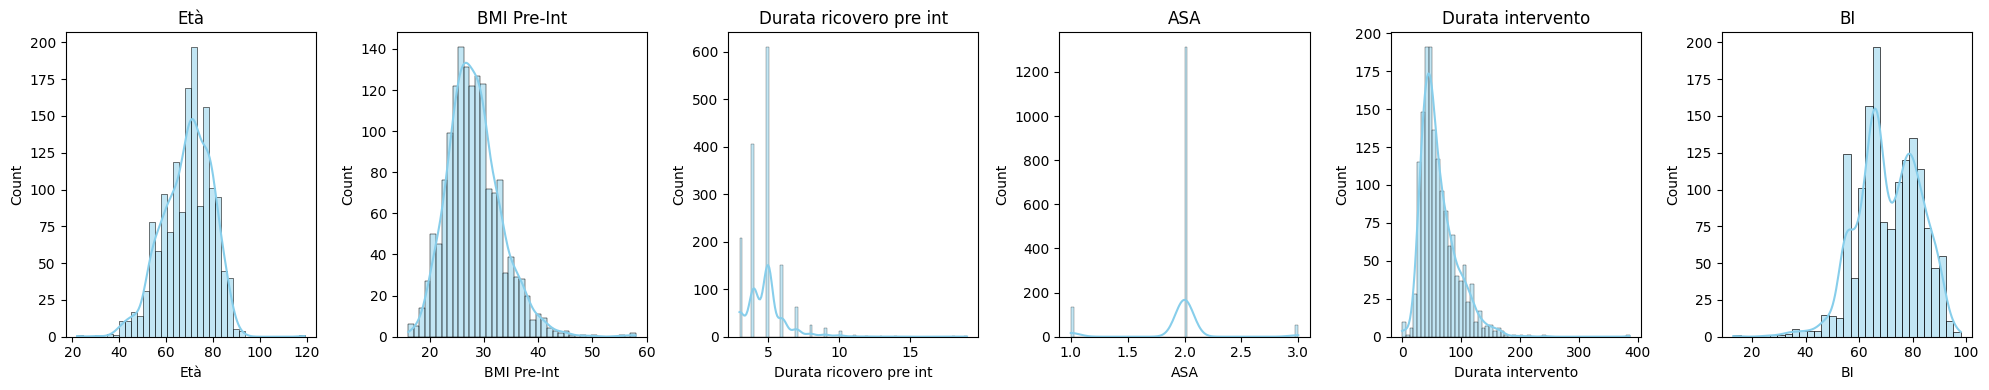

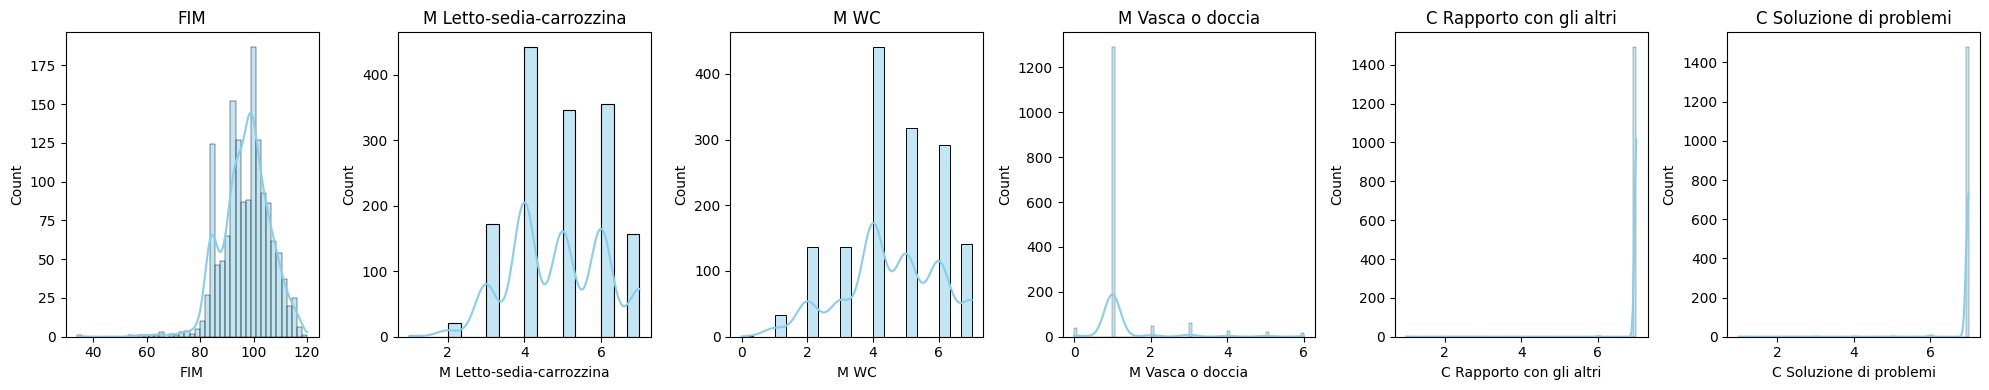

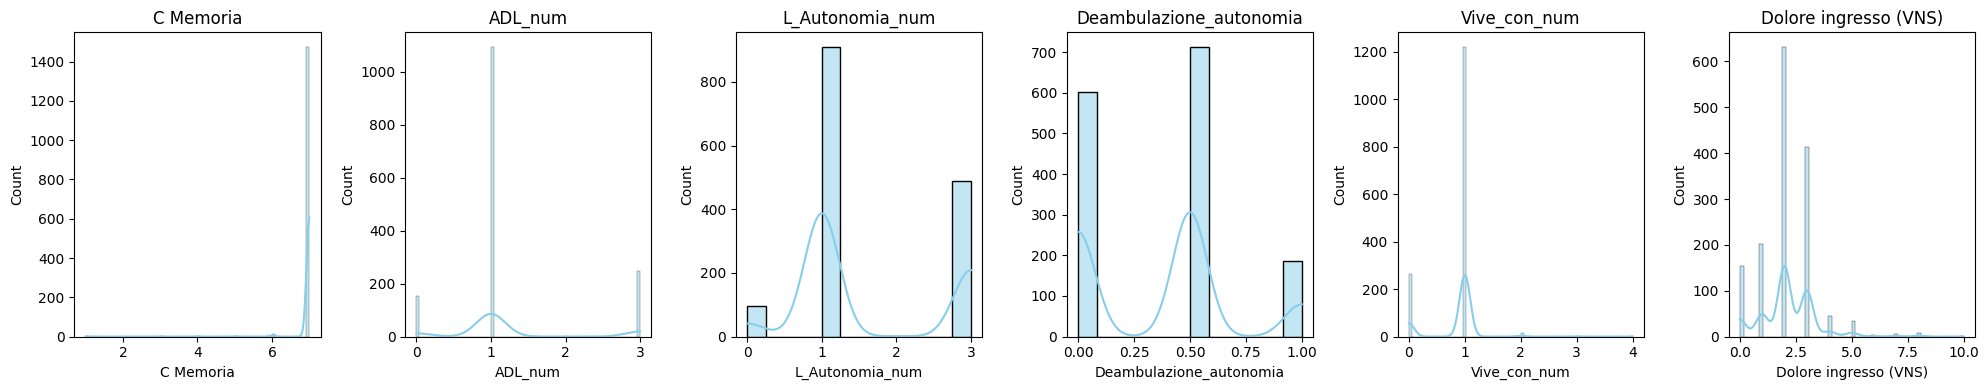

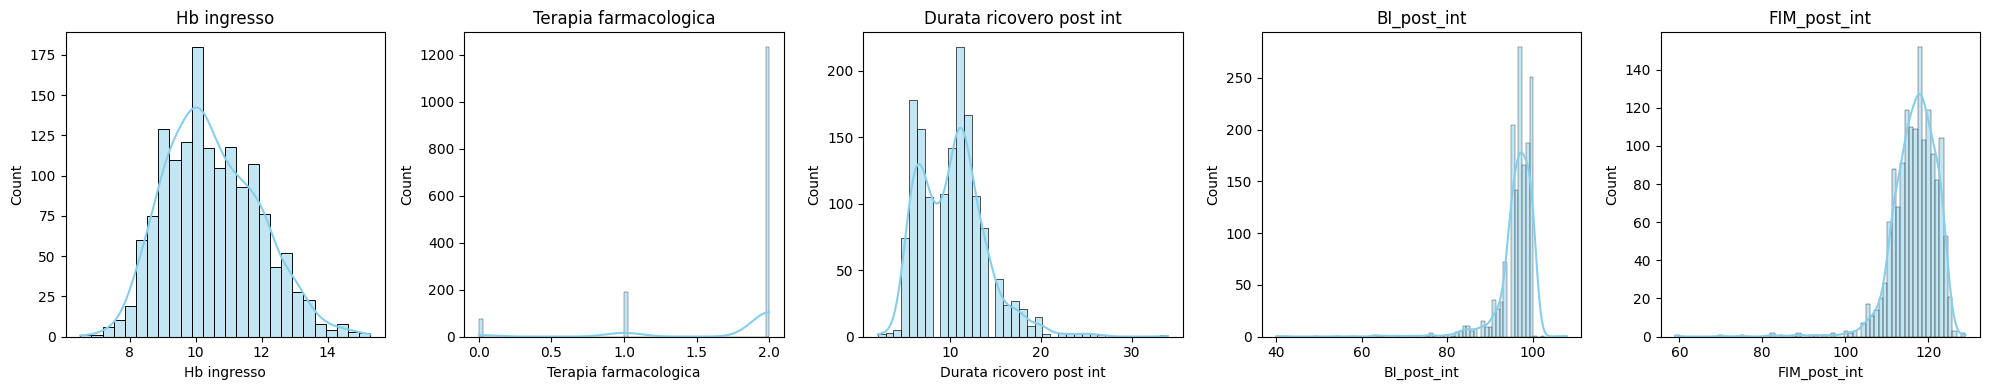

In [227]:


cols_per_fig = 6  # numero di istogrammi per figura

for i in range(0, len(continuous_cols), cols_per_fig):
    subset = continuous_cols[i:i+cols_per_fig]
    n = len(subset)
    
    plt.figure(figsize=(20, 4))
    for j, col in enumerate(subset, 1):
        plt.subplot(1, n, j)
        sns.histplot(XY[col], kde=True, color='skyblue')
        plt.title(col)
    
    plt.tight_layout()
    plt.show()



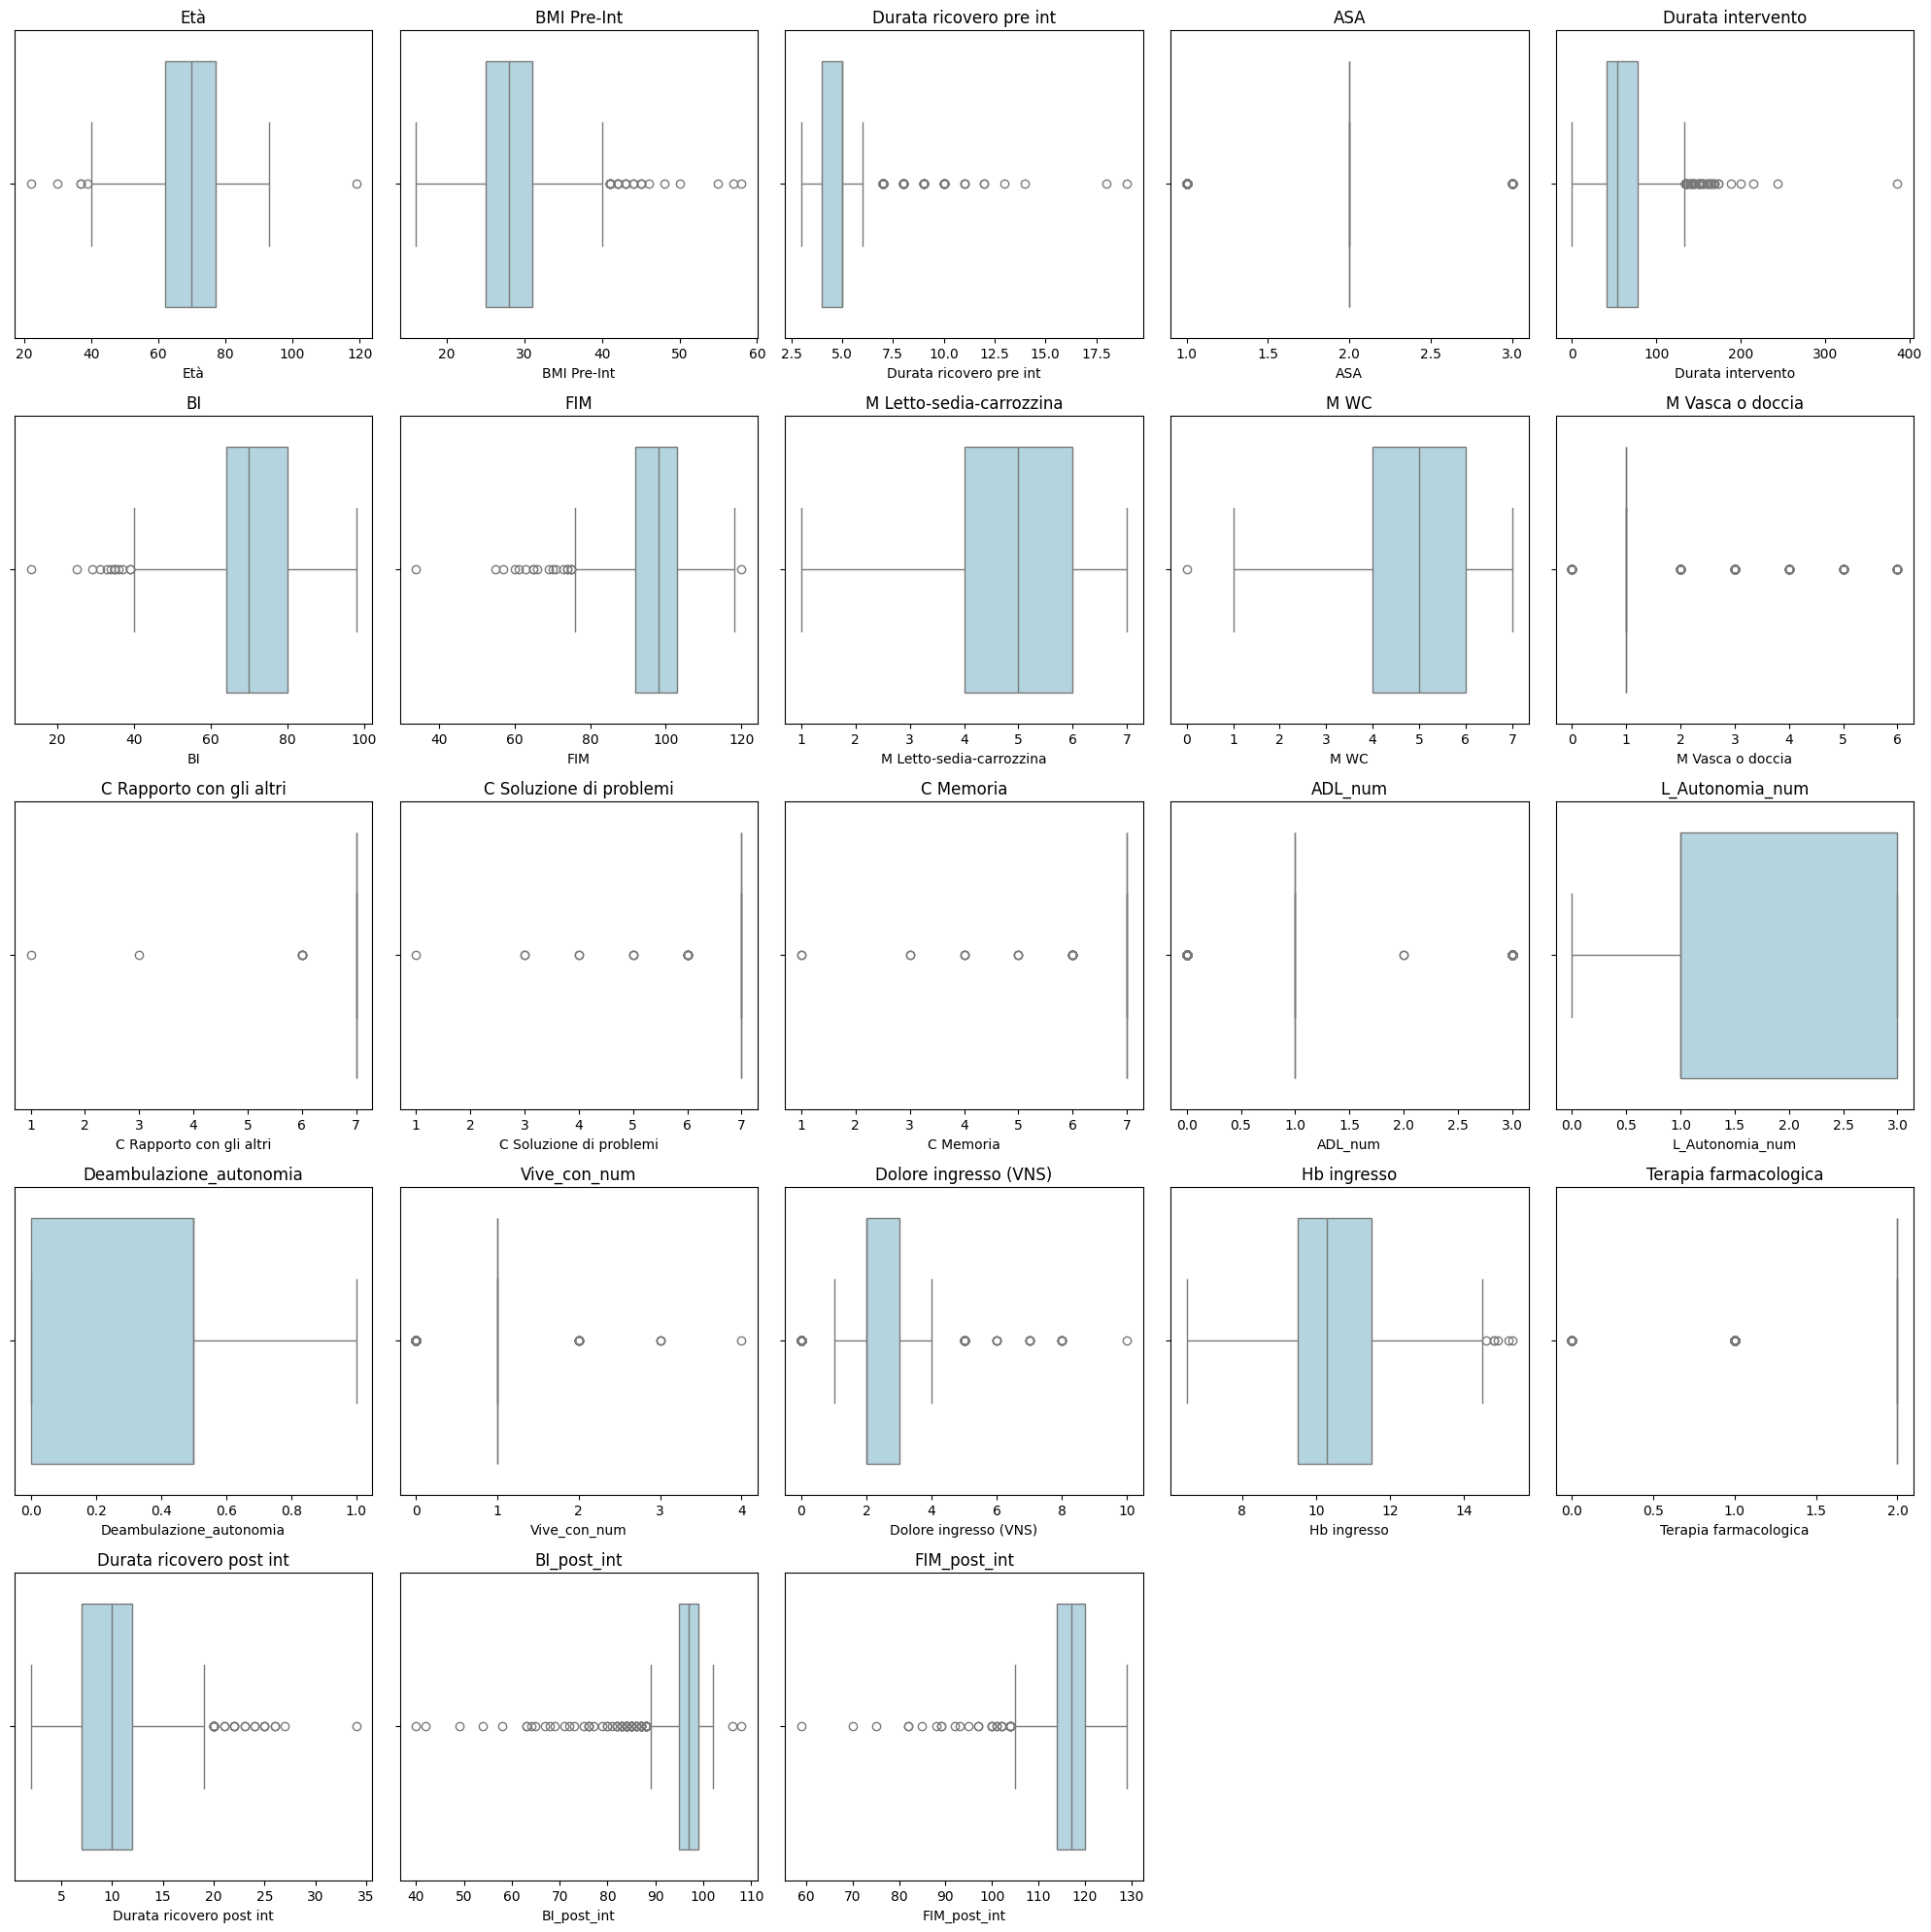

In [228]:
cols = 5
rows = math.ceil(len(continuous_cols) / cols)
plt.figure(figsize=(20, 4 * rows))

for i, col in enumerate(continuous_cols, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(x=XY[col], color='lightblue')
    plt.title(col)

plt.tight_layout()
plt.show()

### Binarie

In [229]:
# Calcola la percentuale di 1 per ogni variabile binaria
binary_summary = XY[binary_cols].mean().sort_values(ascending=False)

# Mostra le prime 20 più frequenti
binary_summary.head(20)


Anestesia_subaracnoidea         0.952635
Procedura_ICD_81.54             0.639093
Diagnosi_ICD_715.16             0.631087
Ipertensione arteriosa          0.581721
AccessoChir_midvastus           0.384923
Sesso_bin                       0.381588
Residenza_Lombardia_cat         0.370914
Procedura_ICD_81.51             0.360907
Diagnosi_ICD_715.15             0.344897
AccessoChir_postero-laterale    0.332889
AccessoChir_pararotuleo         0.248165
Farmaci extra_bin               0.244830
Professione_Attiva              0.144763
Malattie della tiroide          0.142762
Trasfusione                     0.132755
Protesi_ginocchio               0.128753
Diabete                         0.123416
Altro cardiovascolare           0.114743
Protesi_anca                    0.104736
Ipercol. e/o ipertrig.          0.094730
dtype: float64

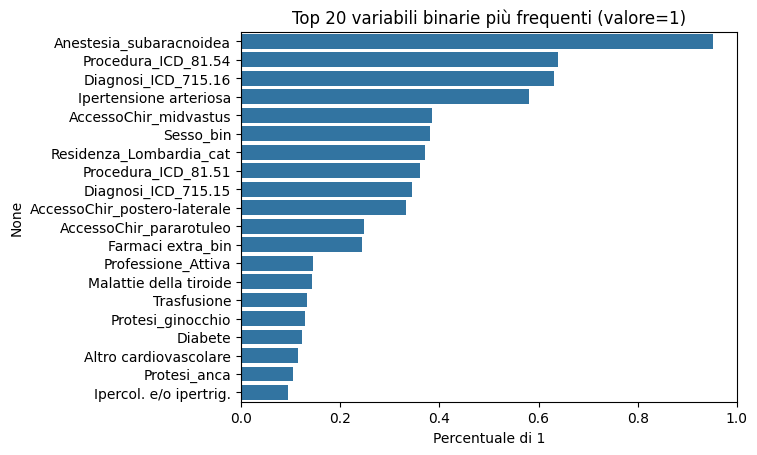

In [230]:
sns.barplot(x=binary_summary.head(20), y=binary_summary.head(20).index)
plt.title("Top 20 variabili binarie più frequenti (valore=1)")
plt.xlabel("Percentuale di 1")
plt.show()


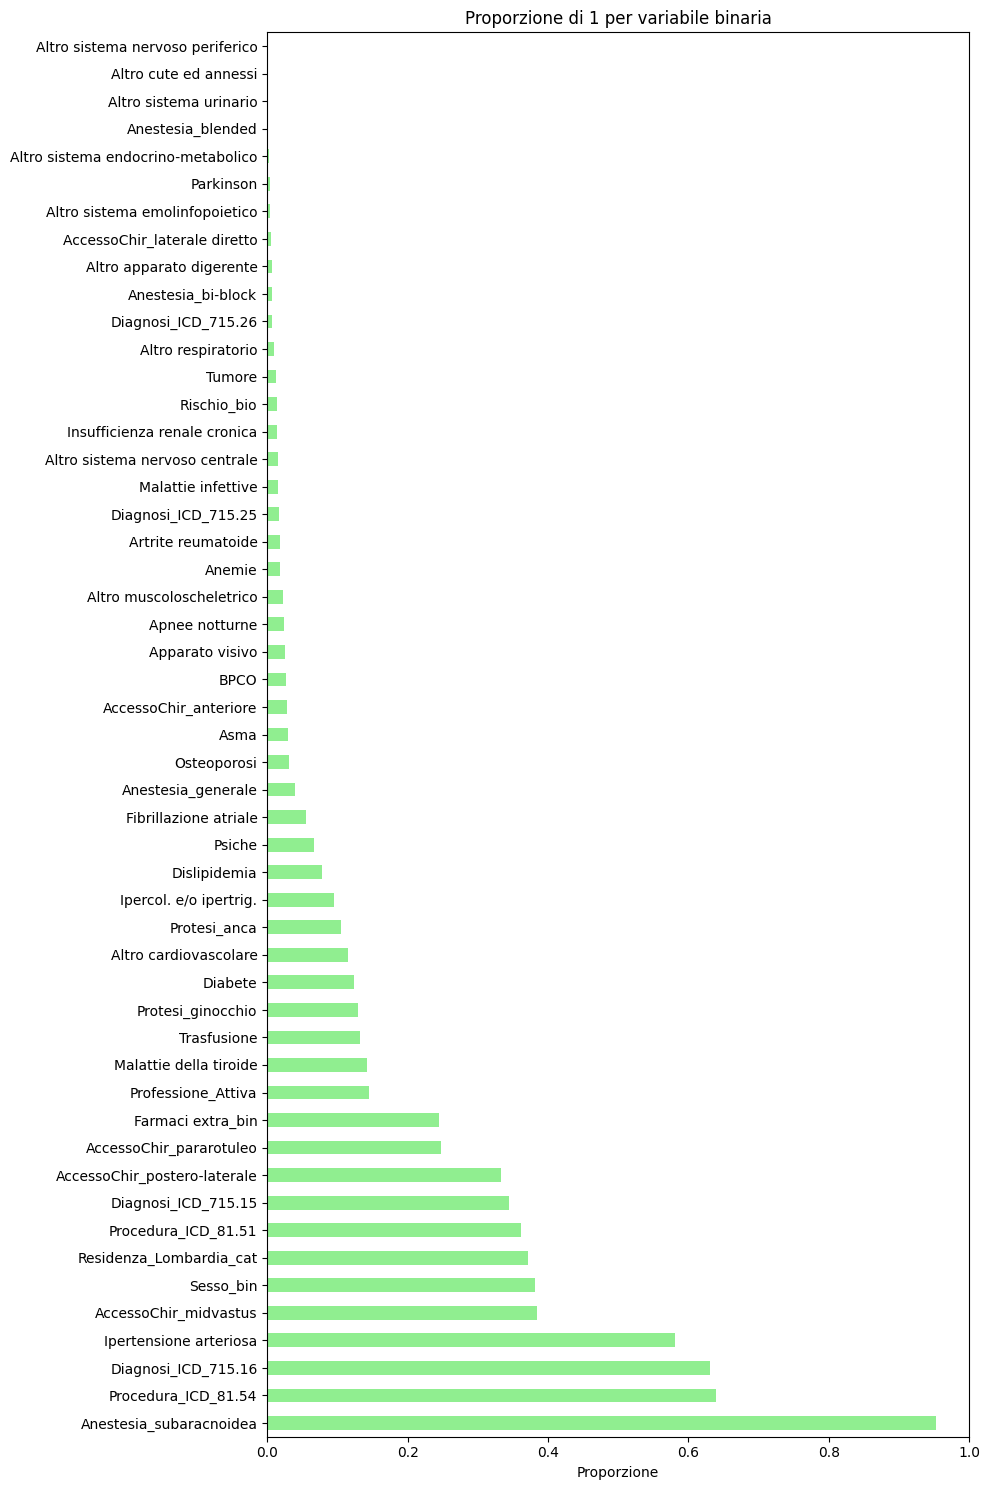

In [231]:

binary_means = XY[binary_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 15))
binary_means.plot(kind='barh', color='lightgreen')
plt.title("Proporzione di 1 per variabile binaria")
plt.xlabel("Proporzione")
plt.tight_layout()
plt.show()


### Categoriche

--- Outcome sociale ---
Outcome sociale
Domicilio con parenti    90.927285
Domicilio da solo         6.004003
Istituto                  3.068712
Name: proportion, dtype: float64



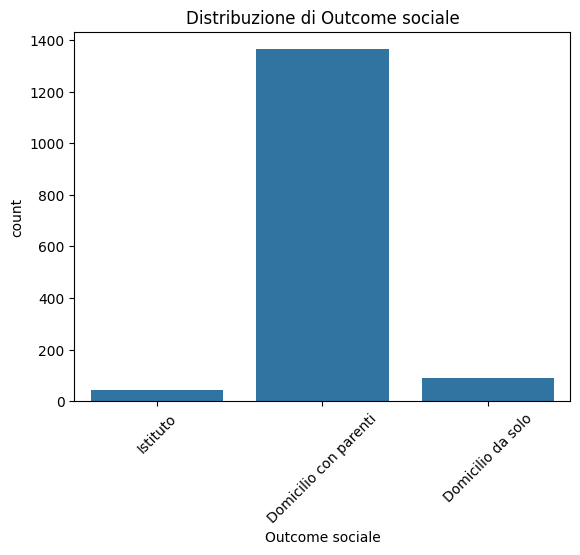

--- Peso Assistenziale ---
Peso Assistenziale
Meno di 3h    75.850567
Nessuno       24.082722
Meno di 6h     0.066711
Name: proportion, dtype: float64



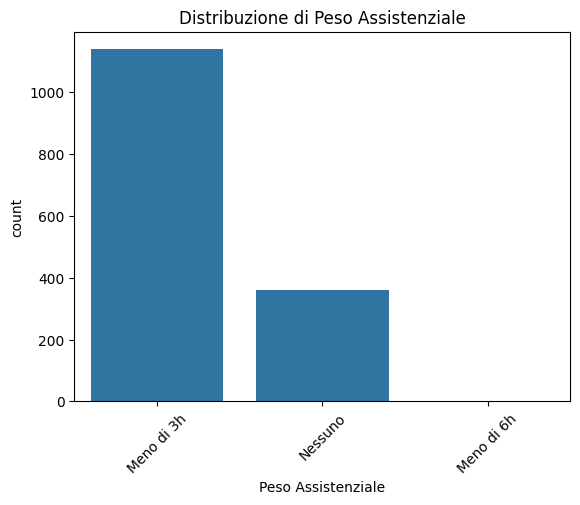

--- Deambulazione.1 ---
Deambulazione.1
Autonomo           94.529686
Autonoma <50m       3.802535
Con supervisore     1.667779
Name: proportion, dtype: float64



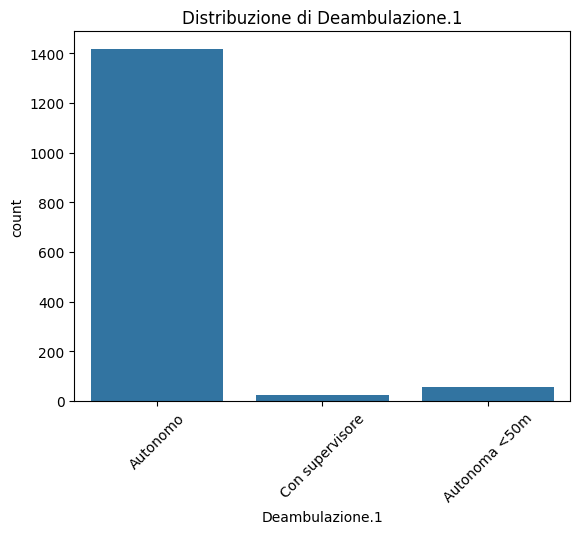

--- Ausili ---
Ausili
2 canadesi      98.532355
Deambulatore     1.200801
Nessuno          0.200133
1 bastone        0.066711
Name: proportion, dtype: float64



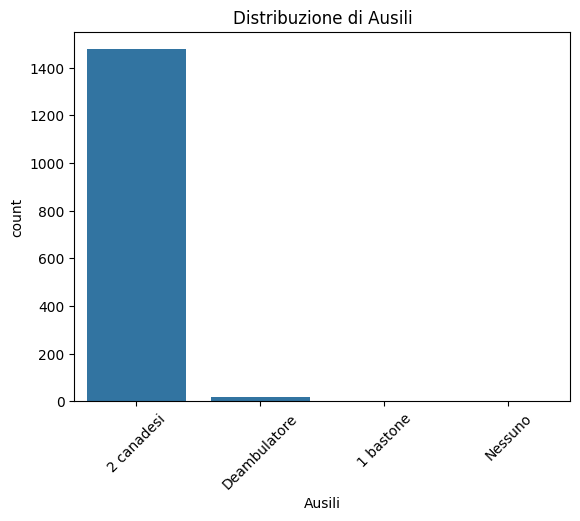

In [232]:
for col in cat_cols:
    print(f"--- {col} ---")
    print(XY[col].value_counts(normalize=True)*100)
    print()
    sns.countplot(x=col, data=XY)
    plt.title(f"Distribuzione di {col}")
    plt.xticks(rotation=45)
    plt.show()


C:\Users\fccat\AppData\Local\Temp\ipykernel_10328\3097340097.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=XY, x=col, palette="Set2")
C:\Users\fccat\AppData\Local\Temp\ipykernel_10328\3097340097.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=XY, x=col, palette="Set2")
C:\Users\fccat\AppData\Local\Temp\ipykernel_10328\3097340097.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=XY, x=col, palette="Set2")
C:\Users\fccat\AppData\Local\Temp\ipykernel_10328\3097340097.py:7: FutureWarning: 

Passing `palette` with

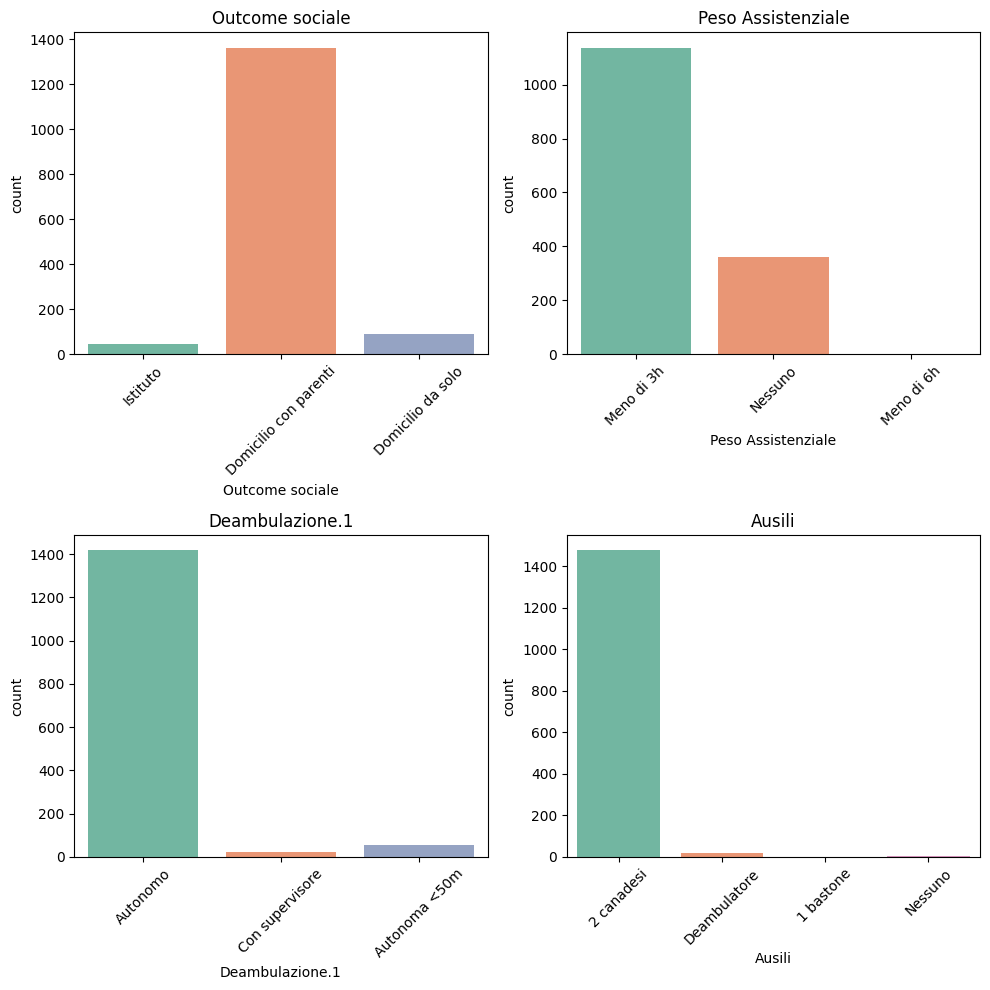

In [233]:
cols = 2  # numero di colonne per riga
rows = math.ceil(len(categorical_cols) / cols)

plt.figure(figsize=(10, 10))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(rows, cols, i)
    sns.countplot(data=XY, x=col, palette="Set2")
    plt.title(col)
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Correlazioni 

Matrice di correlazione: (74, 74)


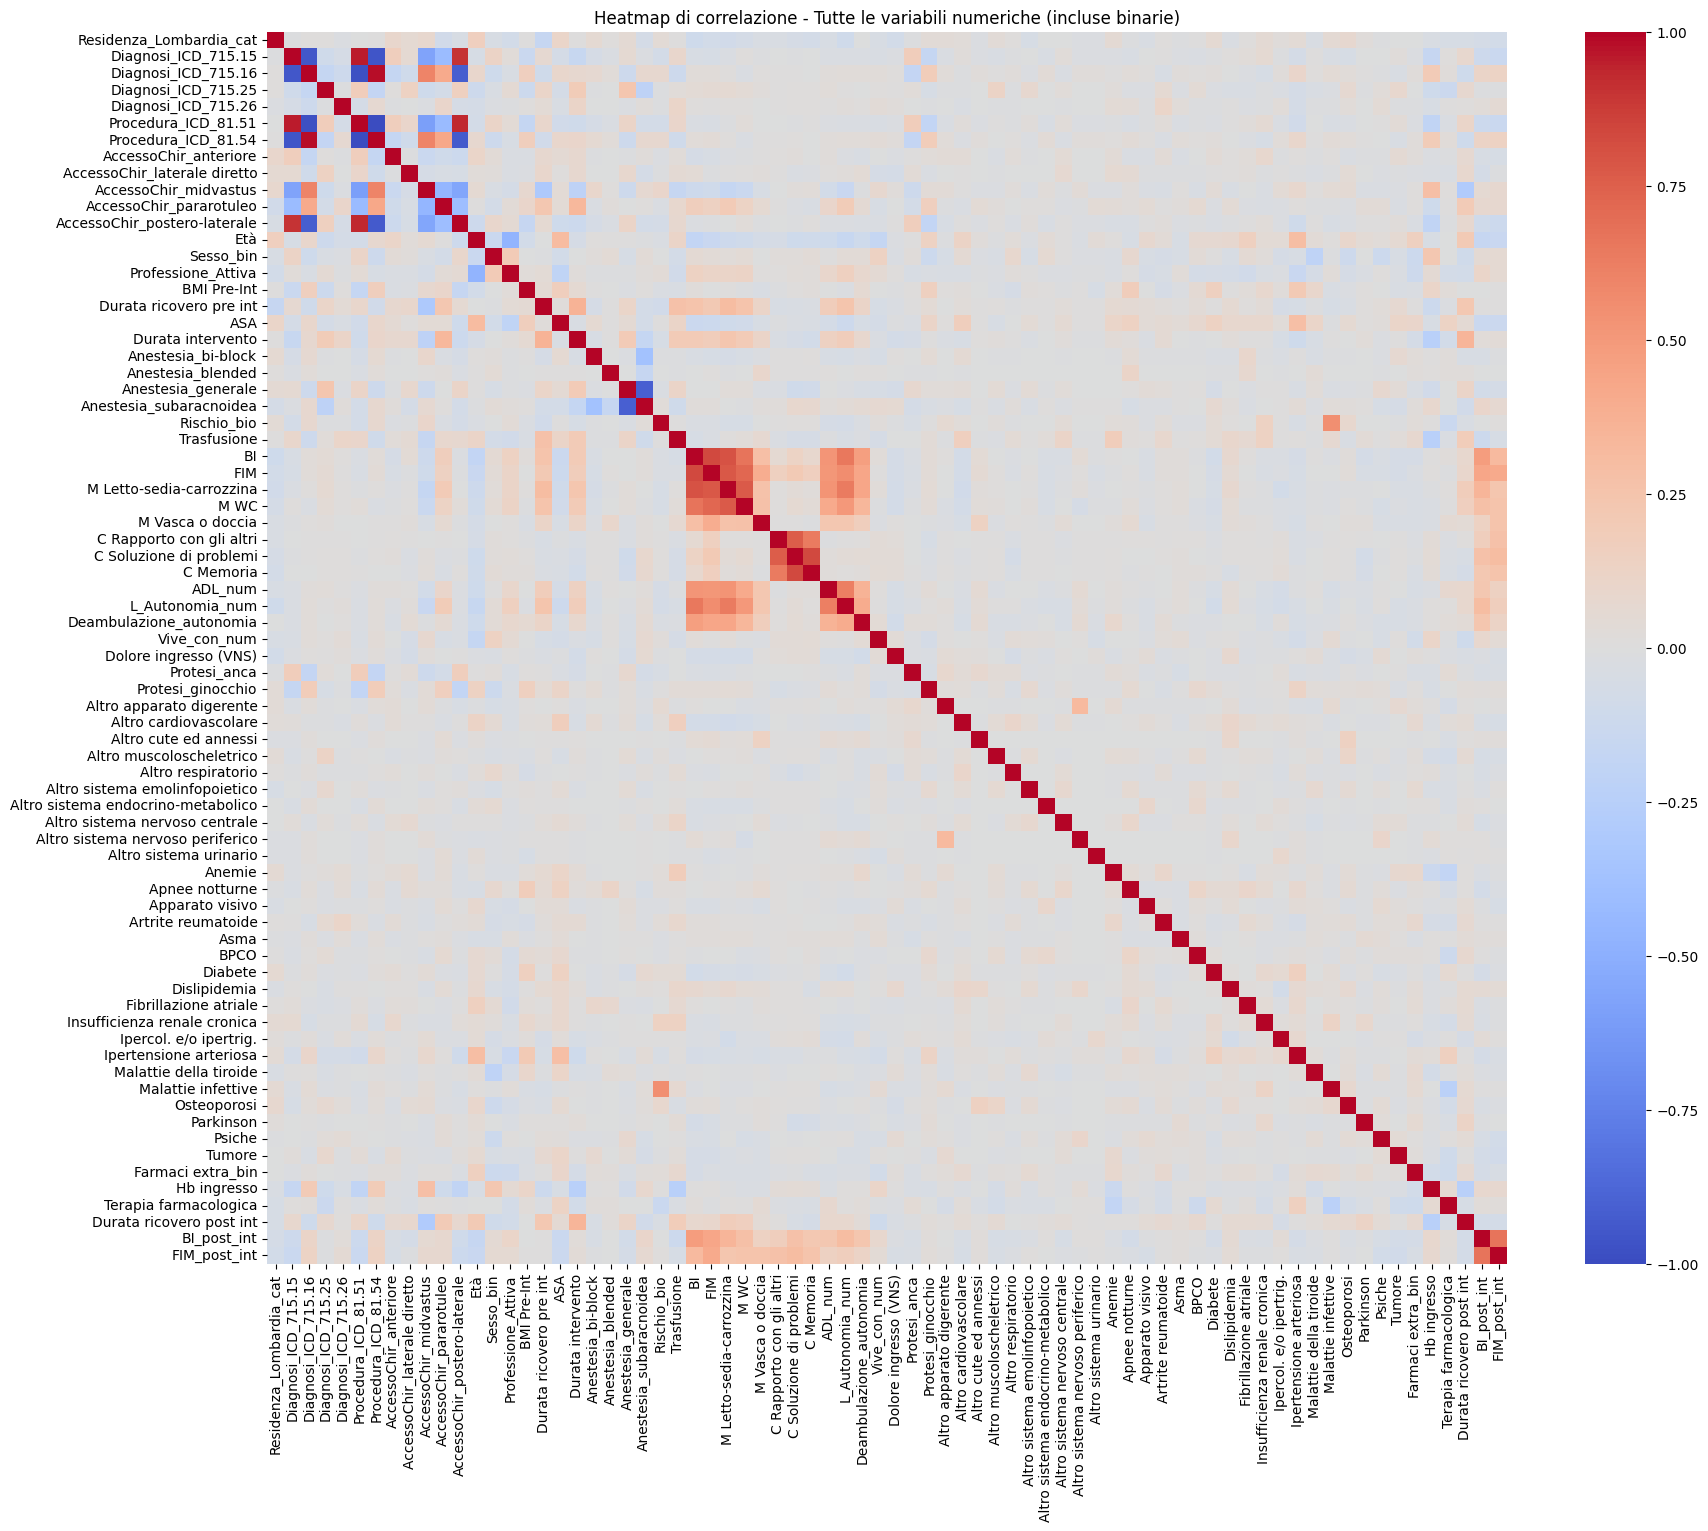

In [234]:
# Seleziona tutte le colonne numeriche (incluse binarie)
num_cols = XY.select_dtypes(include=['int64', 'float64']).columns

# Calcola la matrice di correlazione
corr_matrix = XY[num_cols].corr()

# Visualizza dimensione
print(f"Matrice di correlazione: {corr_matrix.shape}")

# Heatmap completa
plt.figure(figsize=(20, 16))  # aumenta la dimensione per leggibilità
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, cbar=True)
plt.title("Heatmap di correlazione - Tutte le variabili numeriche (incluse binarie)")
plt.show()

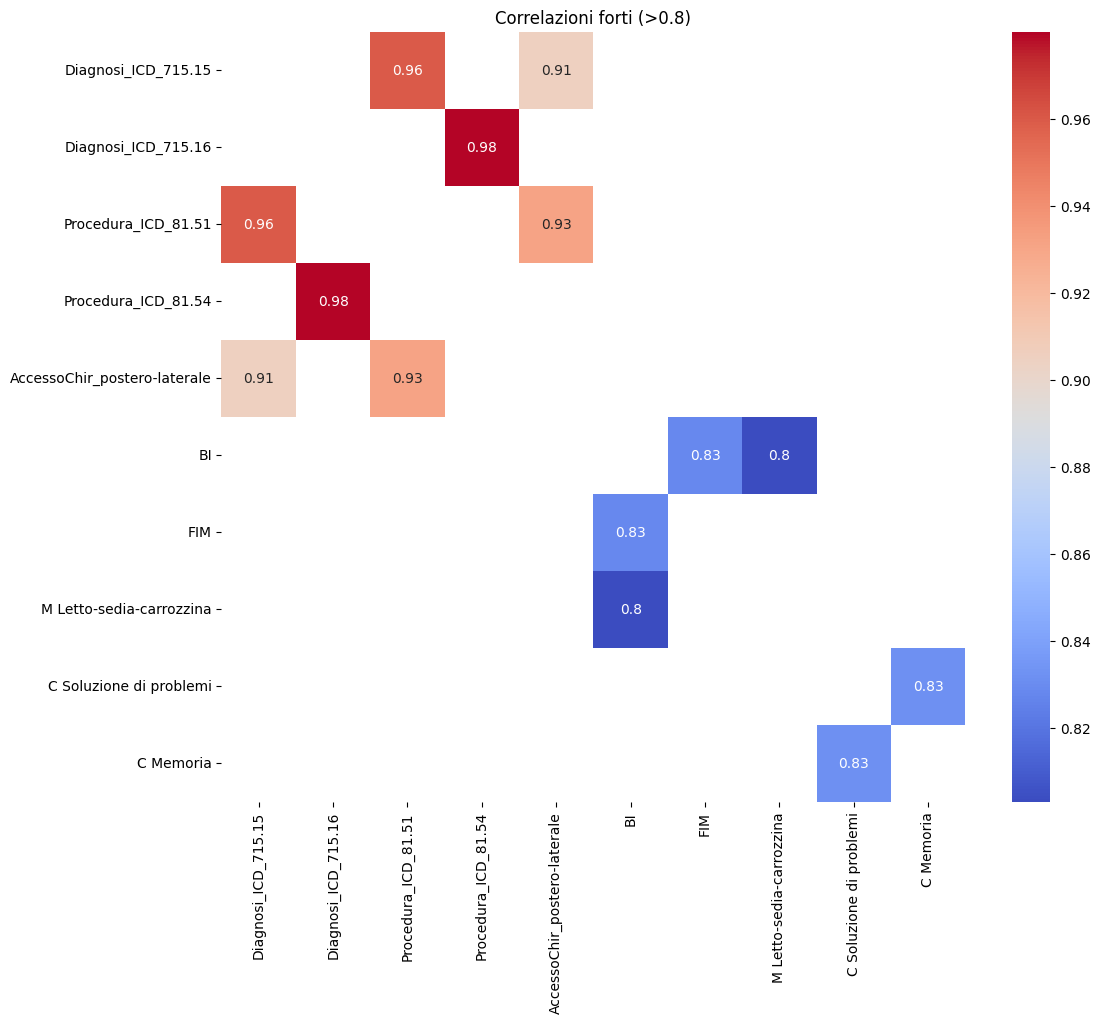

In [235]:
# Mostra solo correlazioni forti (> 0.8)
strong_corr = corr_matrix[(corr_matrix > 0.8) & (corr_matrix < 1.0)].dropna(how='all', axis=0).dropna(how='all', axis=1)

plt.figure(figsize=(12,10))
sns.heatmap(strong_corr, annot=True, cmap="coolwarm")
plt.title("Correlazioni forti (>0.8)")
plt.show()


In [236]:
strong_corrs = corr_matrix[(corr_matrix > 0.8) & (corr_matrix < 1.0)]

strong_pairs = []
for col in strong_corrs.columns:
    for idx in strong_corrs.index:
        if not np.isnan(strong_corrs.loc[idx, col]) and strong_corrs.loc[idx, col] > 0.8:
            strong_pairs.append((idx, col, strong_corrs.loc[idx, col]))

strong_pairs = list(set([tuple(sorted(p[:2])) + (p[2],) for p in strong_pairs]))
strong_pairs


[('Diagnosi_ICD_715.15', 'Procedura_ICD_81.51', np.float64(0.959702988113884)),
 ('BI', 'M Letto-sedia-carrozzina', np.float64(0.8030878324387022)),
 ('Diagnosi_ICD_715.16', 'Procedura_ICD_81.54', np.float64(0.979997535438973)),
 ('C Memoria', 'C Soluzione di problemi', np.float64(0.8317088712111268)),
 ('AccessoChir_postero-laterale',
  'Diagnosi_ICD_715.15',
  np.float64(0.905057522806552)),
 ('BI', 'FIM', np.float64(0.8283915904817037)),
 ('AccessoChir_postero-laterale',
  'Procedura_ICD_81.51',
  np.float64(0.9311713290548933))]

Cerco di raggruppare le variabili correlate in un unica variabile

In [237]:
# --- Indice funzionale ---
XY['Indice_Funzionale'] = XY[['BI', 'FIM', 'M Letto-sedia-carrozzina']].mean(axis=1)
XY.drop(columns=['BI', 'FIM', 'M Letto-sedia-carrozzina'], inplace=True)

# --- Indice cognitivo ---
XY['Indice_Cognitivo'] = XY[['C Soluzione di problemi', 'C Memoria']].mean(axis=1)
XY.drop(columns=['C Soluzione di problemi', 'C Memoria'], inplace=True)

print("✅ Pulizia completata! Nuove variabili create:")
print([col for col in XY.columns if 'Indice' in col or 'Gruppo' in col])

✅ Pulizia completata! Nuove variabili create:
['Indice_Funzionale', 'Indice_Cognitivo']


C:\Users\fccat\AppData\Local\Temp\ipykernel_10328\3478801647.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  XY['Indice_Funzionale'] = XY[['BI', 'FIM', 'M Letto-sedia-carrozzina']].mean(axis=1)
C:\Users\fccat\AppData\Local\Temp\ipykernel_10328\3478801647.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  XY.drop(columns=['BI', 'FIM', 'M Letto-sedia-carrozzina'], inplace=True)
C:\Users\fccat\AppData\Local\Temp\ipykernel_10328\3478801647.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer

In [238]:
XY

,Residenza_Lombardia_cat,Diagnosi_ICD_715.15,Diagnosi_ICD_715.16,Diagnosi_ICD_715.25,Diagnosi_ICD_715.26,Procedura_ICD_81.51,Procedura_ICD_81.54,AccessoChir_anteriore,AccessoChir_laterale diretto,AccessoChir_midvastus,AccessoChir_pararotuleo,AccessoChir_postero-laterale,Età,Sesso_bin,Professione_Attiva,BMI Pre-Int,Durata ricovero pre int,ASA,Durata intervento,Anestesia_bi-block,Anestesia_blended,Anestesia_generale,Anestesia_subaracnoidea,Rischio_bio,Trasfusione,M WC,M Vasca o doccia,C Rapporto con gli altri,ADL_num,L_Autonomia_num,Deambulazione_autonomia,Vive_con_num,Dolore ingresso (VNS),Protesi_anca,Protesi_ginocchio,Altro apparato digerente,Altro cardiovascolare,Altro cute ed annessi,Altro muscoloscheletrico,Altro respiratorio,Altro sistema emolinfopoietico,Altro sistema endocrino-metabolico,Altro sistema nervoso centrale,Altro sistema nervoso periferico,Altro sistema urinario,Anemie,Apnee notturne,Apparato visivo,Artrite reumatoide,Asma,BPCO,Diabete,Dislipidemia,Fibrillazione atriale,Insufficienza renale cronica,Ipercol. e/o ipertrig.,Ipertensione arteriosa,Malattie della tiroide,Malattie infettive,Osteoporosi,Parkinson,Psiche,Tumore,Farmaci extra_bin,Hb ingresso,Terapia farmacologica,Durata ricovero post int,Outcome sociale,Peso Assistenziale,BI_post_int,FIM_post_int,Deambulazione.1,Ausili,Indice_Funzionale,Indice_Cognitivo
0,1,0,1,0,0,0,1,0,0,0,1,0,79,0,0,24,6,2,95,0,0,0,1,0,0,4,2,7,1,1,0.0,0,2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,9.4,1,15,Istituto,Meno di 3h,84,109,Autonomo,2 canadesi,51.666667,7.0
1,1,0,1,0,0,0,1,0,0,0,1,0,73,0,0,26,6,2,121,0,0,0,1,0,0,5,1,7,3,3,1.0,1,2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,9.0,2,16,Domicilio con parenti,Meno di 3h,100,118,Autonomo,2 canadesi,67.333333,7.0
2,1,1,0,0,0,1,0,0,0,0,0,1,73,0,0,23,6,1,88,0,0,0,1,0,0,6,1,7,3,3,0.0,1,2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,10.1,2,10,Domicilio con parenti,Meno di 3h,84,107,Con supervisore,2 canadesi,57.000000,7.0
3,1,0,1,0,0,0,1,0,0,0,1,0,81,0,0,38,6,2,99,0,0,0,1,0,1,6,1,7,3,3,1.0,0,4,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,8.8,1,20,Domicilio con parenti,Nessuno,95,114,Autonomo,2 canadesi,61.666667,7.0
4,1,0,0,1,0,1,0,0,0,0,0,1,74,0,0,17,6,3,106,0,0,1,0,0,1,5,1,7,1,1,0.5,1,2,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,8.6,0,18,Istituto,Meno di 3h,99,115,Autonomo,2 canadesi,50.666667,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1494,1,1,0,0,0,1,0,1,0,0,0,0,63,1,0,26,5,1,68,0,0,0,1,0,0,5,1,7,1,1,1.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,12.1,2,12,Domicilio con parenti,Meno di 3h,99,115,Autonomo,2 canadesi,54.333333,7.0
1495,0,0,1,0,0,0,1,0,0,0,1,0,60,1,1,26,3,2,31,0,0,0,1,0,0,2,1,7,0,0,0.5,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,10.6,2,6,Domicilio con parenti,Meno di 3h,95,118,Autonomo,2 canadesi,47.333333,7.0
1496,1,0,0,1,0,1,0,0,1,0,0,0,79,0,0,21,5,2,96,0,0,0,1,0,0,5,1,7,1,1,1.0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,9.3,2,13,Domicilio con parenti,Nessuno,95,114,Autonomo,2 canadesi,64.666667,7.0
1497,0,0,1,0,0,0,1,0,0,0,1,0,49,1,1,24,4,2,72,0,0,0,1,1,0,5,1,7,1,1,0.5,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,10.0,2,5,Domicilio con parenti,Meno di 3h,97,112,Autonomo,2 canadesi,61.333333,7.0


### Trasformazioni 

In [240]:
# Trova colonne costanti o quasi
constant_cols = [col for col in XY.columns if XY[col].nunique() == 1]
print("Colonne costanti da rimuovere:", constant_cols)


Colonne costanti da rimuovere: []


In [241]:
continuous_cols_sensate= [
    "Età", "BMI Pre-Int", "Durata ricovero pre int", "Durata intervento",
    "Hb ingresso"
]
# Queste sono le principali continue su cui ha senso normalizzare o log-trasformare

In [242]:
# --- 2️⃣ Analisi preliminare: skewness e outlier check ---
print("Skewness delle variabili continue:")
for col in continuous_cols_sensate:
    print(f"{col}: {XY[col].skew():.2f}")

Skewness delle variabili continue:
Età: -0.40
BMI Pre-Int: 0.88
Durata ricovero pre int: 2.47
Durata intervento: 1.85
Hb ingresso: 0.38


In [243]:
# --- 3️⃣ Log-transform per variabili molto skewed ---
# (threshold empirico: skewness > 1)
skewed_cols = [col for col in continuous_cols_sensate if abs(XY[col].skew()) > 1]

XY_transformed = XY.copy()
for col in skewed_cols:
    # Evita log(0) con +1 se necessario
    XY_transformed[col] = np.log1p(XY[col])
    print(f"✔ Log-transform applicato a: {col}")

✔ Log-transform applicato a: Durata ricovero pre int
✔ Log-transform applicato a: Durata intervento


In [244]:
# --- 4️⃣ Normalizzazione ---
standard_cols = [col for col in continuous_cols_sensate if col not in skewed_cols]
scaler_std = StandardScaler()
scaler_robust = RobustScaler()

XY_transformed[standard_cols] = scaler_std.fit_transform(XY_transformed[standard_cols])
XY_transformed[skewed_cols] = scaler_robust.fit_transform(XY_transformed[skewed_cols])

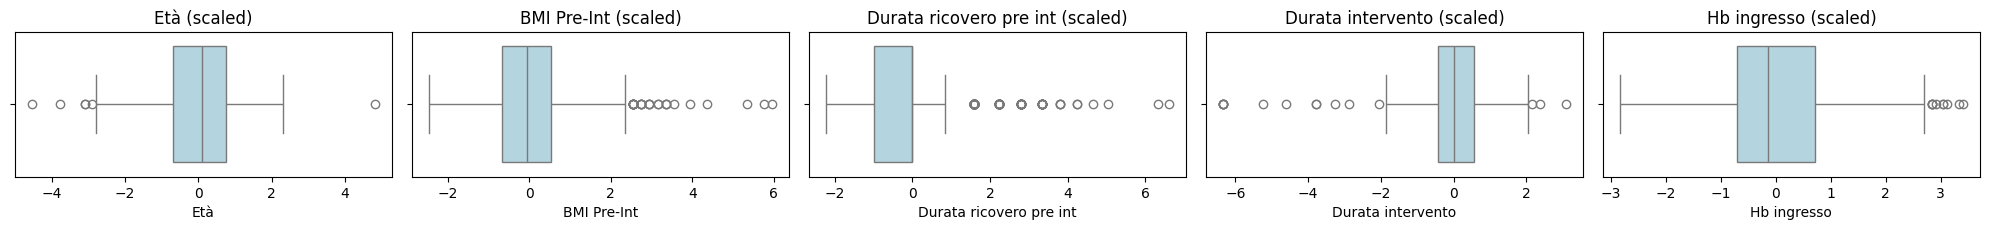

In [245]:
# --- 5️⃣ Visualizzazione post-normalizzazione ---
plt.figure(figsize=(20, 4 * ((len(continuous_cols_sensate) + 4) // 5)))
for i, col in enumerate(continuous_cols_sensate, 1):
    plt.subplot(len(continuous_cols_sensate)//5 + 1, 5, i)
    sns.boxplot(x=XY_transformed[col], color='lightblue')
    plt.title(f"{col} (scaled)")
plt.tight_layout()
plt.show()

In [246]:
# --- 6️⃣ Output finale ---
print("\n✅ Dataset normalizzato pronto per analisi clinica o ML:")
display(XY_transformed)


✅ Dataset normalizzato pronto per analisi clinica o ML:


,Residenza_Lombardia_cat,Diagnosi_ICD_715.15,Diagnosi_ICD_715.16,Diagnosi_ICD_715.25,Diagnosi_ICD_715.26,Procedura_ICD_81.51,Procedura_ICD_81.54,AccessoChir_anteriore,AccessoChir_laterale diretto,AccessoChir_midvastus,AccessoChir_pararotuleo,AccessoChir_postero-laterale,Età,Sesso_bin,Professione_Attiva,BMI Pre-Int,Durata ricovero pre int,ASA,Durata intervento,Anestesia_bi-block,Anestesia_blended,Anestesia_generale,Anestesia_subaracnoidea,Rischio_bio,Trasfusione,M WC,M Vasca o doccia,C Rapporto con gli altri,ADL_num,L_Autonomia_num,Deambulazione_autonomia,Vive_con_num,Dolore ingresso (VNS),Protesi_anca,Protesi_ginocchio,Altro apparato digerente,Altro cardiovascolare,Altro cute ed annessi,Altro muscoloscheletrico,Altro respiratorio,Altro sistema emolinfopoietico,Altro sistema endocrino-metabolico,Altro sistema nervoso centrale,Altro sistema nervoso periferico,Altro sistema urinario,Anemie,Apnee notturne,Apparato visivo,Artrite reumatoide,Asma,BPCO,Diabete,Dislipidemia,Fibrillazione atriale,Insufficienza renale cronica,Ipercol. e/o ipertrig.,Ipertensione arteriosa,Malattie della tiroide,Malattie infettive,Osteoporosi,Parkinson,Psiche,Tumore,Farmaci extra_bin,Hb ingresso,Terapia farmacologica,Durata ricovero post int,Outcome sociale,Peso Assistenziale,BI_post_int,FIM_post_int,Deambulazione.1,Ausili,Indice_Funzionale,Indice_Cognitivo
0,1,0,1,0,0,0,1,0,0,0,1,0,0.957952,0,0,-0.857566,0.845488,2,0.881662,0,0,0,1,0,0,4,2,7,1,1,0.0,0,2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,-0.780889,1,15,Istituto,Meno di 3h,84,109,Autonomo,2 canadesi,51.666667,7.0
1,1,0,1,0,0,0,1,0,0,0,1,0,0.379709,0,0,-0.457102,0.845488,2,1.261025,0,0,0,1,0,0,5,1,7,3,3,1.0,1,2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,-1.064573,2,16,Domicilio con parenti,Meno di 3h,100,118,Autonomo,2 canadesi,67.333333,7.0
2,1,1,0,0,0,1,0,0,0,0,0,1,0.379709,0,0,-1.057799,0.845488,1,0.761823,0,0,0,1,0,0,6,1,7,3,3,0.0,1,2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-0.284441,2,10,Domicilio con parenti,Meno di 3h,84,107,Con supervisore,2 canadesi,57.000000,7.0
3,1,0,1,0,0,0,1,0,0,0,1,0,1.150699,0,0,1.945687,0.845488,2,0.946277,0,0,0,1,0,1,6,1,7,3,3,1.0,0,4,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,-1.206415,1,20,Domicilio con parenti,Nessuno,95,114,Autonomo,2 canadesi,61.666667,7.0
4,1,0,0,1,0,1,0,0,0,0,0,1,0.476083,0,0,-2.259193,0.845488,3,1.053369,0,0,1,0,0,1,5,1,7,1,1,0.5,1,2,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,-1.348257,0,18,Istituto,Meno di 3h,99,115,Autonomo,2 canadesi,50.666667,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1494,1,1,0,0,0,1,0,1,0,0,0,0,-0.584029,1,0,-0.457102,0.000000,1,0.358944,0,0,0,1,0,0,5,1,7,1,1,1.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.133980,2,12,Domicilio con parenti,Meno di 3h,99,115,Autonomo,2 canadesi,54.333333,7.0
1495,0,0,1,0,0,0,1,0,0,0,1,0,-0.873151,1,1,-0.457102,-2.223901,2,-0.857259,0,0,0,1,0,0,2,1,7,0,0,0.5,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.070164,2,6,Domicilio con parenti,Meno di 3h,95,118,Autonomo,2 canadesi,47.333333,7.0
1496,1,0,0,1,0,1,0,0,1,0,0,0,0.957952,0,0,-1.458263,0.000000,2,0.898065,0,0,0,1,0,0,5,1,7,1,1,1.0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,-0.851810,2,13,Domicilio con parenti,Nessuno,95,114,Autonomo,2 canadesi,64.666667,7.0
1497,0,0,1,0,0,0,1,0,0,0,1,0,-1.933262,1,1,-0.857566,-1.000000,2,0.448142,0,0,0,1,1,0,5,1,7,1,1,0.5,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-0.355362,2,5,Domicilio con parenti,Meno di 3h,97,112,Autonomo,2 canadesi,61.333333,7.0


### VIF

In [247]:
num_cols = XY.select_dtypes(include=['float64', 'int64']).columns
# Seleziona solo le variabili numeriche
X_vif = XY[num_cols]

# Aggiungi una costante (necessaria per calcolare il VIF)
X_vif = X_vif.assign(const=1)


In [248]:
# calcolo del VIF
vif_data = pd.DataFrame()
vif_data["Variabile"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i)
                   for i in range(X_vif.shape[1])]

# Rimuovo la colonna della costante
vif_data = vif_data[vif_data["Variabile"] != "const"]

# Ordino dal più alto al più basso
vif_data.sort_values("VIF", ascending=False, inplace=True)

c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


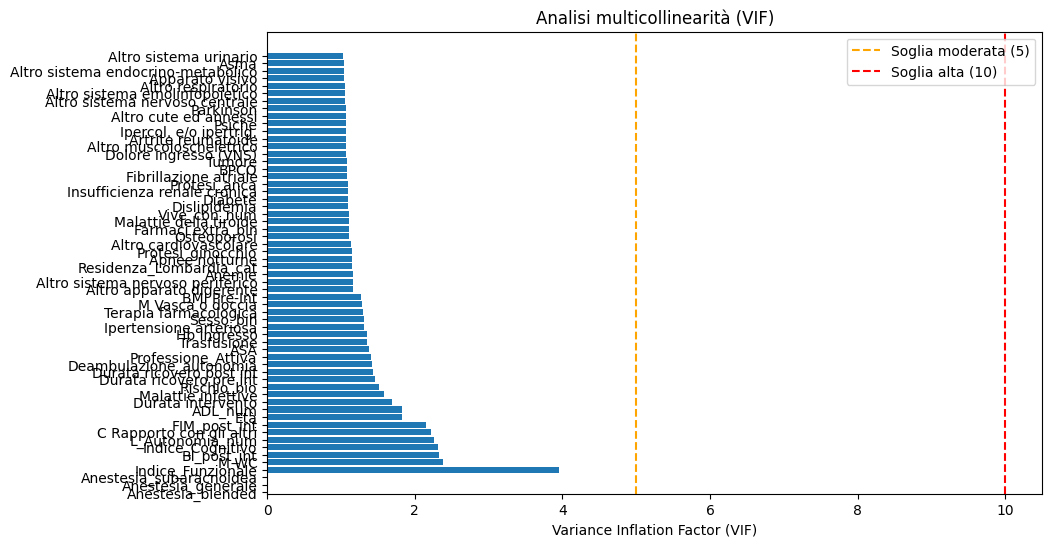

In [249]:

plt.figure(figsize=(10, 6))
plt.barh(vif_data["Variabile"], vif_data["VIF"])
plt.axvline(5, color="orange", linestyle="--", label="Soglia moderata (5)")
plt.axvline(10, color="red", linestyle="--", label="Soglia alta (10)")
plt.xlabel("Variance Inflation Factor (VIF)")
plt.title("Analisi multicollinearità (VIF)")
plt.legend()
plt.show()


# Saving Data

In [ ]:
XY_transformed.to_csv("C:/Users/fccat/Desktop/MUDI Lab/Data for ML.csv")
XY.to_csv('C:/Users/fccat/Desktop/MUDI Lab/EDA_Output_no_trans.csv', index=False)

In [251]:
XY_transformed

,Residenza_Lombardia_cat,Diagnosi_ICD_715.15,Diagnosi_ICD_715.16,Diagnosi_ICD_715.25,Diagnosi_ICD_715.26,Procedura_ICD_81.51,Procedura_ICD_81.54,AccessoChir_anteriore,AccessoChir_laterale diretto,AccessoChir_midvastus,AccessoChir_pararotuleo,AccessoChir_postero-laterale,Età,Sesso_bin,Professione_Attiva,BMI Pre-Int,Durata ricovero pre int,ASA,Durata intervento,Anestesia_bi-block,Anestesia_blended,Anestesia_generale,Anestesia_subaracnoidea,Rischio_bio,Trasfusione,M WC,M Vasca o doccia,C Rapporto con gli altri,ADL_num,L_Autonomia_num,Deambulazione_autonomia,Vive_con_num,Dolore ingresso (VNS),Protesi_anca,Protesi_ginocchio,Altro apparato digerente,Altro cardiovascolare,Altro cute ed annessi,Altro muscoloscheletrico,Altro respiratorio,Altro sistema emolinfopoietico,Altro sistema endocrino-metabolico,Altro sistema nervoso centrale,Altro sistema nervoso periferico,Altro sistema urinario,Anemie,Apnee notturne,Apparato visivo,Artrite reumatoide,Asma,BPCO,Diabete,Dislipidemia,Fibrillazione atriale,Insufficienza renale cronica,Ipercol. e/o ipertrig.,Ipertensione arteriosa,Malattie della tiroide,Malattie infettive,Osteoporosi,Parkinson,Psiche,Tumore,Farmaci extra_bin,Hb ingresso,Terapia farmacologica,Durata ricovero post int,Outcome sociale,Peso Assistenziale,BI_post_int,FIM_post_int,Deambulazione.1,Ausili,Indice_Funzionale,Indice_Cognitivo
0,1,0,1,0,0,0,1,0,0,0,1,0,0.957952,0,0,-0.857566,0.845488,2,0.881662,0,0,0,1,0,0,4,2,7,1,1,0.0,0,2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,-0.780889,1,15,Istituto,Meno di 3h,84,109,Autonomo,2 canadesi,51.666667,7.0
1,1,0,1,0,0,0,1,0,0,0,1,0,0.379709,0,0,-0.457102,0.845488,2,1.261025,0,0,0,1,0,0,5,1,7,3,3,1.0,1,2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,-1.064573,2,16,Domicilio con parenti,Meno di 3h,100,118,Autonomo,2 canadesi,67.333333,7.0
2,1,1,0,0,0,1,0,0,0,0,0,1,0.379709,0,0,-1.057799,0.845488,1,0.761823,0,0,0,1,0,0,6,1,7,3,3,0.0,1,2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-0.284441,2,10,Domicilio con parenti,Meno di 3h,84,107,Con supervisore,2 canadesi,57.000000,7.0
3,1,0,1,0,0,0,1,0,0,0,1,0,1.150699,0,0,1.945687,0.845488,2,0.946277,0,0,0,1,0,1,6,1,7,3,3,1.0,0,4,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,-1.206415,1,20,Domicilio con parenti,Nessuno,95,114,Autonomo,2 canadesi,61.666667,7.0
4,1,0,0,1,0,1,0,0,0,0,0,1,0.476083,0,0,-2.259193,0.845488,3,1.053369,0,0,1,0,0,1,5,1,7,1,1,0.5,1,2,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,-1.348257,0,18,Istituto,Meno di 3h,99,115,Autonomo,2 canadesi,50.666667,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1494,1,1,0,0,0,1,0,1,0,0,0,0,-0.584029,1,0,-0.457102,0.000000,1,0.358944,0,0,0,1,0,0,5,1,7,1,1,1.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.133980,2,12,Domicilio con parenti,Meno di 3h,99,115,Autonomo,2 canadesi,54.333333,7.0
1495,0,0,1,0,0,0,1,0,0,0,1,0,-0.873151,1,1,-0.457102,-2.223901,2,-0.857259,0,0,0,1,0,0,2,1,7,0,0,0.5,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.070164,2,6,Domicilio con parenti,Meno di 3h,95,118,Autonomo,2 canadesi,47.333333,7.0
1496,1,0,0,1,0,1,0,0,1,0,0,0,0.957952,0,0,-1.458263,0.000000,2,0.898065,0,0,0,1,0,0,5,1,7,1,1,1.0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,-0.851810,2,13,Domicilio con parenti,Nessuno,95,114,Autonomo,2 canadesi,64.666667,7.0
1497,0,0,1,0,0,0,1,0,0,0,1,0,-1.933262,1,1,-0.857566,-1.000000,2,0.448142,0,0,0,1,1,0,5,1,7,1,1,0.5,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-0.355362,2,5,Domicilio con parenti,Meno di 3h,97,112,Autonomo,2 canadesi,61.333333,7.0
